In [1]:
from functools import partial
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap, jit
from jax_helpers import gg_space, glob_inh, sigmoid, softmax
from jax_scaffold_theta import Scaffold
from tqdm import tqdm
import matplotlib.pyplot as plt
jax.config.update('jax_default_matmul_precision', 'highest')

In [51]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)
scaffold = Scaffold(400, lambdas, 'sigmoid', gg_exc=9, gg_inh=-5, gamma=0.6)


g0_target = jnp.asarray(scaffold.grid)
h0        = jnp.asarray(scaffold.hc)
g0_init   = jnp.zeros_like(g0_target)      # start g at zero — this is the recall task
h0_norm   = jnp.linalg.norm(h0, axis=0)    # this is per pattern norm

freq_range = np.arange(0.0, 5.0, 0.1)
duty_range = np.arange(0.1, 1.1, 0.1)
FF, DD = np.meshgrid(freq_range, duty_range, indexing='ij')
freq_flat = jnp.asarray(FF.ravel())
duty_flat = jnp.asarray(DD.ravel())

vmapped_run = jax.jit(
    jax.vmap(
        Scaffold.simulate_run_sampled,
        in_axes=(None, None, None, None, None, None, None, None, None, 0, 0, None, None),
        #         g0    h0   weights lambdas  b   tau_g tau_h activation dt  freq duty phase
    ),
    static_argnames=('lambdas', 'activation', 'n_steps'),
)


In [15]:
def score_theta(weights, chunk_size=50, n_steps=250, dt=0.1):
    grid_chunks, hc_chunks = [], []
    n = freq_flat.shape[0]
    for start in tqdm(range(0, n, chunk_size)):
        f_chunk = freq_flat[start:start + chunk_size]
        d_chunk = duty_flat[start:start + chunk_size]

        g_sampled, h_sampled = vmapped_run(
            g0_init, h0, weights, lambdas_static,
            scaffold.b, scaffold.tau_g, scaffold.tau_h, sigmoid, dt,
            f_chunk, d_chunk, 0.0, n_steps,
        )

        grid_err = jnp.max(jnp.abs(g_sampled - g0_target[None]), axis=1)          # (chunk, patts)
        hc_err   = jnp.linalg.norm(h_sampled - h0[None], axis=1) / h0_norm[None]  # (chunk, patts)

        grid_chunks.append(np.asarray(grid_err))
        hc_chunks.append(np.asarray(hc_err))

    grid_errors = np.concatenate(grid_chunks, axis=0).reshape(len(freq_range), len(duty_range), -1)
    hc_errors   = np.concatenate(hc_chunks, axis=0).reshape(len(freq_range), len(duty_range), -1)
    return grid_errors, hc_errors

In [52]:
grid_errors, hc_errors = score_theta(scaffold.weights)

100%|██████████| 10/10 [01:48<00:00, 10.87s/it]


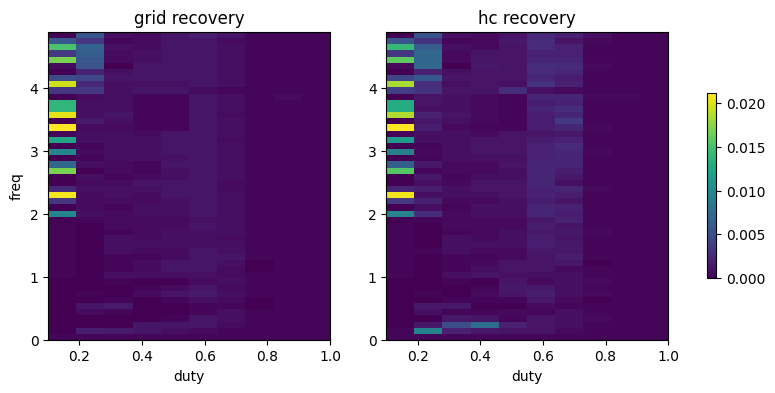

In [53]:
frac_grid = np.mean(grid_errors < 0.2, axis=-1)
frac_hc   = np.mean(hc_errors < 0.4, axis=-1)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(frac_grid, origin='lower', vmin=0,
                    extent=[duty_range[0], duty_range[-1], freq_range[0], freq_range[-1]], aspect='auto')
ax[0].set_xlabel('duty'); ax[0].set_ylabel('freq'); ax[0].set_title('grid recovery')
im1 = ax[1].imshow(frac_hc, origin='lower', vmin=0,
                    extent=[duty_range[0], duty_range[-1], freq_range[0], freq_range[-1]], aspect='auto')
ax[1].set_xlabel('duty'); ax[1].set_title('hc recovery')
fig.colorbar(im1, ax=ax, shrink=0.6)

In [50]:
flat_idx = np.argmax(frac_grid)
coords = np.unravel_index(flat_idx, frac_grid.shape)
print(coords)
print(freq_range[coords[0]], duty_range[coords[1]])
print(np.max(frac_grid[0]), np.max(frac_grid[1:, :-1]))

print(np.argmin(grid_errors[coords[0], coords[1], :]))

flat_idx = np.argmax(frac_hc)
coords = np.unravel_index(flat_idx, frac_hc.shape)
print(coords)
print(freq_range[coords[0]], duty_range[coords[1]])
print(np.max(frac_hc[0]), np.max(frac_hc[1:, :-1]))


(np.int64(2), np.int64(3))
0.2 0.4
0.0 0.79
1078
(np.int64(2), np.int64(4))
0.2 0.5
0.0 0.8386111111111111


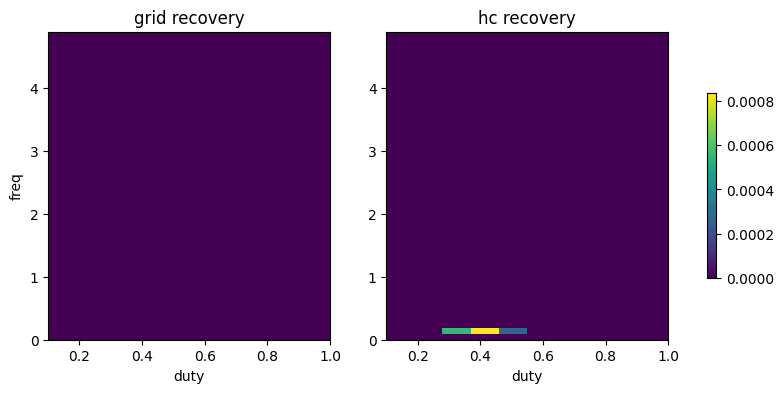

In [ ]:
frac_grid = np.mean(grid_errors < 0.2, axis=-1)
frac_hc   = np.mean(hc_errors < 0.4, axis=-1)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(frac_grid, origin='lower', vmin=0,
                    extent=[duty_range[0], duty_range[-1], freq_range[0], freq_range[-1]], aspect='auto')
ax[0].set_xlabel('duty'); ax[0].set_ylabel('freq'); ax[0].set_title('grid recovery')
im1 = ax[1].imshow(frac_hc, origin='lower', vmin=0,
                    extent=[duty_range[0], duty_range[-1], freq_range[0], freq_range[-1]], aspect='auto')
ax[1].set_xlabel('duty'); ax[1].set_title('hc recovery')
fig.colorbar(im1, ax=ax, shrink=0.6)

In [37]:
flat_idx = np.argmax(frac_grid)
coords = np.unravel_index(flat_idx, frac_grid.shape)
print(coords)
print(freq_range[coords[0]], duty_range[coords[1]])
print(np.max(frac_grid[0]), np.max(frac_grid[1:, :-1]))

(np.int64(1), np.int64(7))
0.1 0.8
0.4583333333333333 0.45944444444444443
